- Câu hỏi: Thảo luận về tầm quan trọng cũng như các ứng dụng thực tế của gom cụm (clustering) trong phân tích dữ liệu.
-> Câu trả lời: Gom cụm quan trọng vì giúp khám phá cấu trúc ẩn trong dữ liệu khi chưa có nhãn, hỗ trợ phân tích và ra quyết định. Ứng dụng thực tế gồm phân khúc khách hàng, phát hiện bất thường/gian lận, nhóm tài liệu hoặc ảnh, và hỗ trợ phân tích dữ liệu không gian.

- Câu hỏi: Nêu rõ các mục tiêu chính của gom cụm, cụ thể là việc nhóm các điểm dữ liệu có tính chất tương đồng lại với nhau.
-> Câu trả lời: Mục tiêu chính của gom cụm là tạo các nhóm sao cho các điểm trong cùng cụm có mức độ tương đồng cao, còn giữa các cụm thì khác biệt rõ ràng.

- Câu hỏi: Giải thích sự khác biệt giữa hai phương pháp gom cụm (dựa trên mật độ và dựa trên lưới) so với các phương pháp truyền thống như phân vùng (partitioning) và phân cấp (hierarchical).
-> Câu trả lời: Gom cụm dựa trên mật độ xác định cụm theo vùng có mật độ điểm cao và tách nhiễu, phù hợp cụm hình dạng bất quy tắc. Gom cụm dựa trên lưới chia không gian thành các ô và gom cụm theo mật độ trên các ô, tối ưu khi xử lý dữ liệu lớn. Trong khi đó, phân vùng thường chia dữ liệu thành số cụm định trước dựa trên tối ưu khoảng cách, còn phân cấp xây cây cụm theo quá trình gộp/tách mà không dựa trực tiếp vào mật độ hoặc lưới.

## Hoạt động 2: Gom cụm dựa trên mật độ (Density-Based Clustering)

- Câu hỏi: Trình bày về các phương pháp gom cụm dựa trên mật độ, lấy thuật toán DBSCAN làm trọng tâm.
-> Câu trả lời: Ý tưởng của gom cụm dựa trên mật độ là: vùng nào có nhiều điểm tập trung thì là cụm, vùng thưa thì không phải cụm. DBSCAN là thuật toán tiêu biểu vì không cần khai báo trước số cụm. DBSCAN dùng 2 tham số chính: `eps` (bán kính lân cận) và `min_samples` (số điểm tối thiểu trong bán kính đó để một điểm được xem là điểm lõi).
Ví dụ cụ thể: nếu `eps=0.3`, `min_samples=8`, một điểm sẽ được xem là thuộc vùng cụm khi trong bán kính 0.3 của nó có ít nhất 8 điểm.

- Câu hỏi: Giải thích cơ chế hoạt động của DBSCAN và phân tích các ưu điểm của nó, đặc biệt nhấn mạnh vào khả năng xử lý nhiễu (noise) và nhận diện các cụm có hình dạng bất quy tắc (irregularly shaped clusters).
-> Câu trả lời: DBSCAN bắt đầu từ điểm lõi, sau đó mở rộng cụm bằng cách đi qua các điểm lân cận có thể kết nối mật độ với nhau. Điểm không thể kết nối với cụm nào sẽ bị gán nhãn `-1` (noise). Vì dựa trên mật độ kết nối chứ không ép cụm phải tròn, DBSCAN nhận diện tốt cụm cong hoặc kéo dài.
Ví dụ cụ thể: trong kết quả bạn đã chạy ở cell thực hành, các điểm nằm rải rác xa vùng tập trung sẽ bị gán `-1` và không bị ép vào cụm gần nhất.

- Câu hỏi: Phần thực hành mã nguồn với tập dữ liệu từ Kaggle.
-> Câu trả lời: Phần thực hành đã làm theo quy trình: đọc dữ liệu, chọn cột số, chuẩn hóa bằng `StandardScaler`, chạy `DBSCAN`, sau đó vẽ biểu đồ màu theo nhãn cụm.
Ví dụ cụ thể: notebook đang dùng file `Clustering_gmm.csv`, lấy 2 cột số đầu tiên để trực quan hóa kết quả phân cụm.

- Câu hỏi: Phần tinh chỉnh mô hình bằng cách thay đổi `epsilon` và `minimum points`.
-> Câu trả lời: Khi tăng `eps`, vùng lân cận rộng hơn nên nhiều điểm dễ nối thành cụm hơn; khi tăng `min_samples`, tiêu chuẩn để tạo cụm chặt hơn nên thường tăng điểm nhiễu. Vì vậy cần thử nhiều cấu hình để cân bằng giữa số cụm và tỷ lệ nhiễu.
Ví dụ cụ thể: cell tinh chỉnh đã thử các cặp `(0.2,5)`, `(0.3,8)`, `(0.5,10)`, `(0.7,12)` để so sánh trực tiếp ảnh hưởng lên `clusters` và `noise`.

Kích thước dữ liệu: (500, 2)


,Weight,Height
0,67.062924,176.086355
1,68.804094,178.388669
2,60.930863,170.284496
3,59.733843,168.691992
4,65.431230,173.763679


So cum tim duoc: 2
So diem nhieu: 1


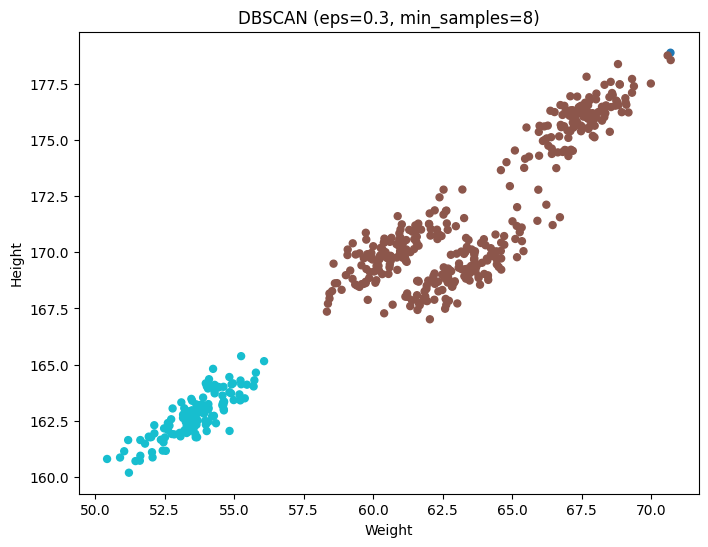

In [1]:
# Hoạt động 2 thực hành
# Yêu cầu: tải dữ liệu từ Kaggle và lưu file CSV vào cùng thư mục notebook.
# Ví dụ tên file: dataset.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

DATA_FILE = Path("Clustering_gmm.csv")

if not DATA_FILE.exists():
    raise FileNotFoundError(
        "Không tìm thấy dataset.csv. Hãy tải dữ liệu từ Kaggle và đặt file vào thư mục lab/Slot_19_LAB_4.3/."
    )

df = pd.read_csv(DATA_FILE)
print("Kích thước dữ liệu:", df.shape)
display(df.head())

# Tự động chọn 2 cột số đầu tiên để trực quan hóa cụm
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) < 2:
    raise ValueError("Dữ liệu cần ít nhất 2 cột số để chạy và vẽ DBSCAN.")

selected_cols = numeric_cols[:2]
X = df[selected_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Thiết lập tham số DBSCAN ban đầu
eps = 0.3
min_samples = 8

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()
print(f"So cum tim duoc: {n_clusters}")
print(f"So diem nhieu: {n_noise}")

plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels, cmap="tab10", s=25)
plt.xlabel(selected_cols[0])
plt.ylabel(selected_cols[1])
plt.title(f"DBSCAN (eps={eps}, min_samples={min_samples})")
plt.show()

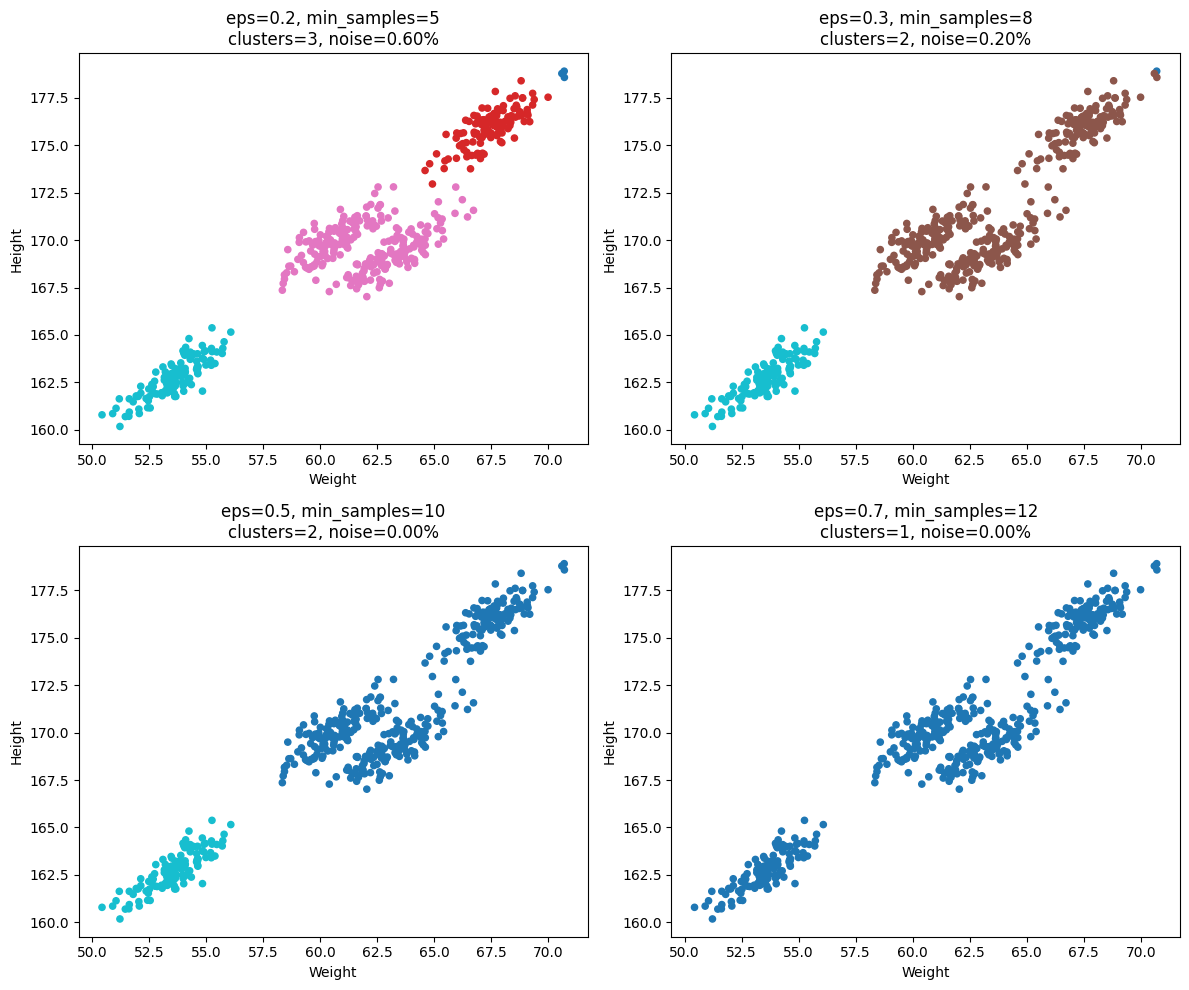

In [2]:
# Hoạt động 2 thực hành - tinh chỉnh tham số DBSCAN

import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

param_grid = [
    (0.2, 5),
    (0.3, 8),
    (0.5, 10),
    (0.7, 12),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, (eps, min_samples) in enumerate(param_grid):
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels_tuned = model.fit_predict(X_scaled)

    n_clusters = len(set(labels_tuned)) - (1 if -1 in labels_tuned else 0)
    noise_ratio = (labels_tuned == -1).sum() / len(labels_tuned)

    axes[i].scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels_tuned, cmap="tab10", s=20)
    axes[i].set_title(
        f"eps={eps}, min_samples={min_samples}\nclusters={n_clusters}, noise={noise_ratio:.2%}"
    )
    axes[i].set_xlabel(selected_cols[0])
    axes[i].set_ylabel(selected_cols[1])

plt.tight_layout()
plt.show()

## Hoạt động 3: Gom cụm dựa trên lưới (Grid-Based Clustering)

- Câu hỏi: Trình bày về các phương pháp gom cụm dựa trên không gian lưới, tiêu biểu là thuật toán CLIQUE.
-> Câu trả lời: Gom cụm dựa trên lưới chia không gian dữ liệu thành các ô nhỏ trước, rồi phân cụm theo mật độ trong từng ô thay vì xét trực tiếp từng điểm. CLIQUE là đại diện tiêu biểu vì cách làm này giúp xử lý nhanh hơn trên dữ liệu lớn và nhiều chiều.
Ví dụ cụ thể: trong notebook, không gian 2D (Weight, Height) được chia thành `grid_size x grid_size`, sau đó xét ô nào đủ đậm đặc để thuộc cụm.

- Câu hỏi: Giải thích cách thuật toán CLIQUE chia không gian dữ liệu thành các ô lưới (grids) và cách nó xác định những vùng có mật độ dữ liệu cao.
-> Câu trả lời: Mỗi chiều được chia thành các khoảng đều nhau để tạo thành các ô lưới. Với mỗi ô, ta đếm số điểm rơi vào ô đó. Nếu số điểm đạt ngưỡng tối thiểu thì ô được xem là ô dày đặc. Các ô dày đặc kề nhau sẽ được gộp thành cùng một cụm.
Ví dụ cụ thể: trong code thực hành, điều kiện ô dày đặc là `len(pts) >= min_points`; các ô kề nhau theo 8 hướng được duyệt và gộp bằng BFS.

- Câu hỏi: Phần thực hành mã nguồn: sử dụng tập dữ liệu được giao để áp dụng CLIQUE.
-> Câu trả lời: Phần thực hành đã mô phỏng đúng ý tưởng CLIQUE: ánh xạ điểm vào ô lưới, lọc ô dày đặc, gộp ô liên thông và gán nhãn cụm cho từng điểm.
Ví dụ cụ thể: với cấu hình mặc định ở notebook (`grid_size=20`, `min_points=5`), mô hình trả về 3 cụm và 90 điểm nhiễu.

- Câu hỏi: Phần tinh chỉnh mô hình: thay đổi grid sizes và minimum density thresholds.
-> Câu trả lời: Tăng `grid_size` làm ô nhỏ hơn (chi tiết hơn), thường tăng khả năng tách cụm nhưng cũng dễ tăng nhiễu. Tăng `min_points` làm tiêu chuẩn ô dày đặc khắt khe hơn, nên số ô được giữ lại giảm.
Ví dụ cụ thể: cell tinh chỉnh thử các cấu hình `(12,4)`, `(16,5)`, `(20,6)`, `(24,8)` để so sánh sự thay đổi số cụm và tỷ lệ nhiễu.

So cum tim duoc: 3
So diem nhieu: 90


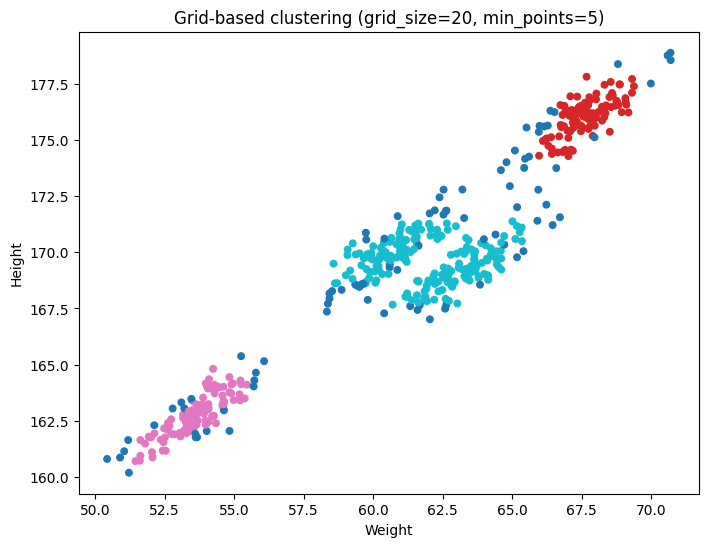

In [3]:
# Hoạt động 3 thực hành
# Mô phỏng Grid-based clustering theo ý tưởng CLIQUE (2D):
# 1) Chia không gian thành lưới đều
# 2) Giữ các ô có mật độ >= min_points
# 3) Gộp các ô dày đặc kề nhau (8-neighborhood)

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, deque

# Dùng lại 2 cột số đã chọn ở Hoạt động 2
if "X" not in globals():
    raise ValueError("Chưa có biến X. Hãy chạy cell Hoạt động 2 thực hành trước.")

X_grid = X.to_numpy()


def grid_clustering(X2d, grid_size=20, min_points=5):
    x_min, y_min = X2d.min(axis=0)
    x_max, y_max = X2d.max(axis=0)

    # Tránh chia cho 0 nếu dữ liệu có biên quá hẹp
    x_span = max(x_max - x_min, 1e-9)
    y_span = max(y_max - y_min, 1e-9)

    # Ánh xạ điểm -> chỉ số ô lưới
    cell_x = np.floor((X2d[:, 0] - x_min) / x_span * grid_size).astype(int)
    cell_y = np.floor((X2d[:, 1] - y_min) / y_span * grid_size).astype(int)
    cell_x = np.clip(cell_x, 0, grid_size - 1)
    cell_y = np.clip(cell_y, 0, grid_size - 1)

    point_cells = list(zip(cell_x, cell_y))
    cell_points = defaultdict(list)
    for idx, c in enumerate(point_cells):
        cell_points[c].append(idx)

    dense_cells = {c for c, pts in cell_points.items() if len(pts) >= min_points}

    # Gom nhóm các ô dày đặc liên thông
    visited = set()
    cell_cluster = {}
    cluster_id = 0

    for cell in dense_cells:
        if cell in visited:
            continue
        queue = deque([cell])
        visited.add(cell)
        while queue:
            cur = queue.popleft()
            cell_cluster[cur] = cluster_id
            cx, cy = cur
            for dx in (-1, 0, 1):
                for dy in (-1, 0, 1):
                    if dx == 0 and dy == 0:
                        continue
                    nb = (cx + dx, cy + dy)
                    if nb in dense_cells and nb not in visited:
                        visited.add(nb)
                        queue.append(nb)
        cluster_id += 1

    labels = np.full(X2d.shape[0], -1, dtype=int)
    for c, pts in cell_points.items():
        if c in cell_cluster:
            labels[pts] = cell_cluster[c]

    return labels


# Cấu hình ban đầu
grid_size = 20
min_points = 5
labels_grid = grid_clustering(X_grid, grid_size=grid_size, min_points=min_points)

n_clusters_grid = len(set(labels_grid)) - (1 if -1 in labels_grid else 0)
n_noise_grid = int((labels_grid == -1).sum())

print(f"So cum tim duoc: {n_clusters_grid}")
print(f"So diem nhieu: {n_noise_grid}")

plt.figure(figsize=(8, 6))
plt.scatter(X_grid[:, 0], X_grid[:, 1], c=labels_grid, cmap="tab10", s=22)
plt.xlabel(selected_cols[0])
plt.ylabel(selected_cols[1])
plt.title(f"Grid-based clustering (grid_size={grid_size}, min_points={min_points})")
plt.show()

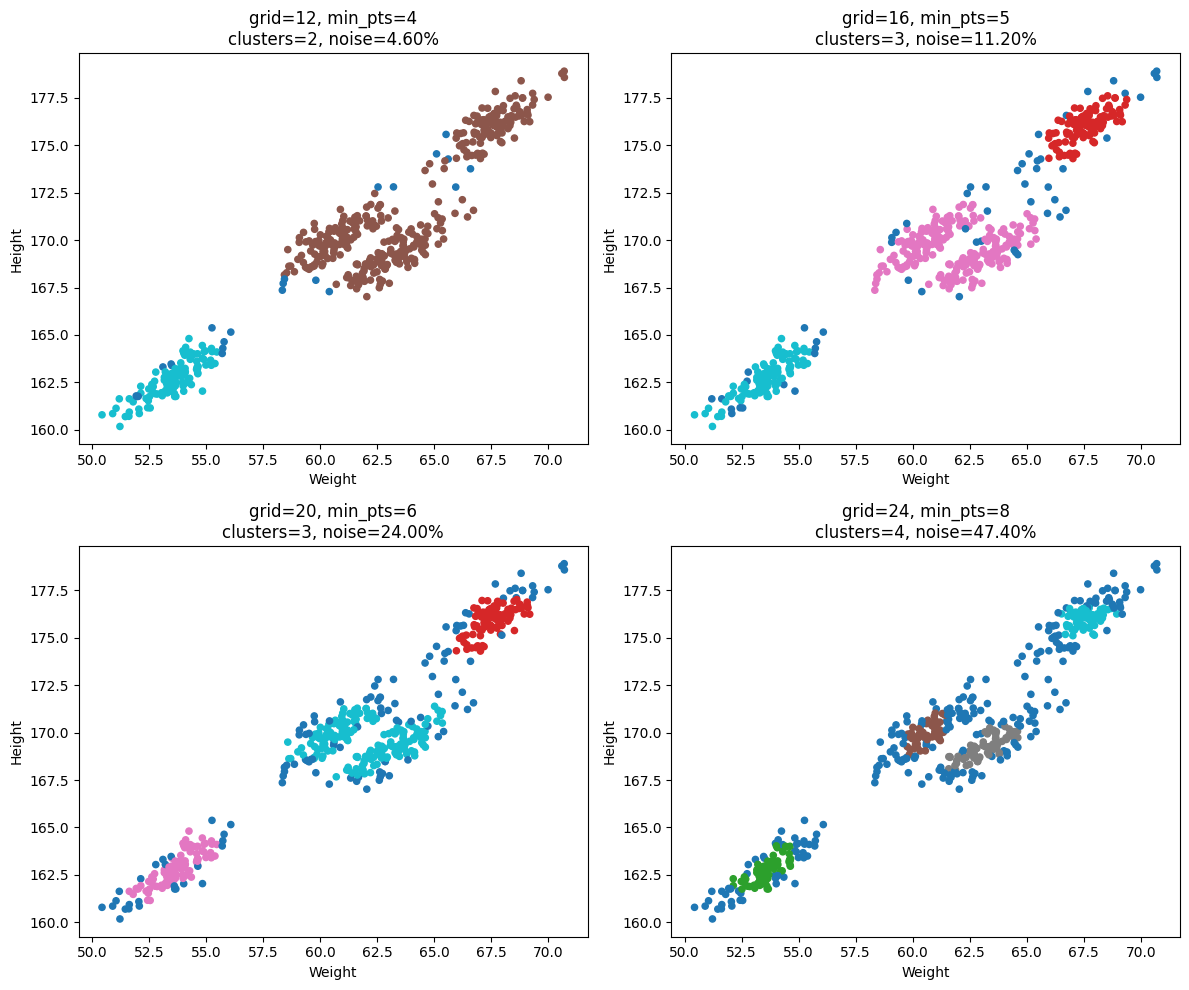

In [5]:
# Hoạt động 3 thực hành - tinh chỉnh grid_size và min_points

param_grid_clique = [
    (12, 4),
    (16, 5),
    (20, 6),
    (24, 8),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, (grid_size, min_points) in enumerate(param_grid_clique):
    labels_tuned_grid = grid_clustering(X_grid, grid_size=grid_size, min_points=min_points)

    n_clusters_tuned = len(set(labels_tuned_grid)) - (1 if -1 in labels_tuned_grid else 0)
    noise_ratio_tuned = (labels_tuned_grid == -1).sum() / len(labels_tuned_grid)

    axes[i].scatter(X_grid[:, 0], X_grid[:, 1], c=labels_tuned_grid, cmap="tab10", s=20)
    axes[i].set_title(
        f"grid={grid_size}, min_pts={min_points}\nclusters={n_clusters_tuned}, noise={noise_ratio_tuned:.2%}"
    )
    axes[i].set_xlabel(selected_cols[0])
    axes[i].set_ylabel(selected_cols[1])

plt.tight_layout()
plt.show()

## Hoạt động 4: So sánh và Thảo luận (Comparison and Discussion)

- Câu hỏi: Tiến hành so sánh chi tiết giữa hai phương pháp: gom cụm dựa trên mật độ và gom cụm dựa trên lưới.
-> Câu trả lời: DBSCAN làm việc trực tiếp trên từng điểm và quan hệ lân cận giữa các điểm. CLIQUE làm việc qua lớp trung gian là lưới (ô), rồi gom cụm bằng các ô dày đặc liên thông. Vì vậy DBSCAN thường bám hình dạng cụm mượt hơn, còn CLIQUE đổi lại tốc độ và khả năng mở rộng tốt hơn.
Ví dụ cụ thể: trên dữ liệu Weight-Height, DBSCAN nhận diện cụm dựa trên vùng điểm dày; còn mô hình CLIQUE trong notebook nhận diện cụm theo vùng ô lưới có mật độ cao.

- Câu hỏi: Đưa ra các ưu điểm và nhược điểm của từng phương pháp.
-> Câu trả lời: DBSCAN: ưu điểm là phát hiện cụm bất quy tắc và lọc nhiễu tốt; nhược điểm là nhạy với `eps`, `min_samples` và khó ổn định khi mật độ các cụm chênh lệch lớn. CLIQUE: ưu điểm là nhanh, dễ mở rộng cho dữ liệu lớn/nhiều chiều; nhược điểm là kết quả phụ thuộc mạnh vào `grid_size` và `min_points`, có thể làm biên cụm bị thô do chia ô.
Ví dụ cụ thể: với cấu hình CLIQUE chặt hơn như `grid=24, min_pts=8`, tỷ lệ noise tăng rõ rệt; trong khi cấu hình thưa hơn như `grid=12, min_pts=4` cho ít noise hơn nhưng cụm có thể bị gộp nhiều hơn.

- Câu hỏi: Dựa trên các ưu/nhược điểm đó, thảo luận xem mỗi phương pháp sẽ phù hợp để áp dụng cho những loại tập dữ liệu nào trong thực tế.
-> Câu trả lời: Nên chọn DBSCAN khi dữ liệu có nhiễu, cụm hình dạng phức tạp và chưa biết trước số cụm. Nên chọn CLIQUE khi dữ liệu rất lớn hoặc nhiều chiều, cần xử lý nhanh và chấp nhận mức xấp xỉ theo lưới.
Ví dụ cụ thể: phát hiện cụm điểm bất thường trong dữ liệu vị trí GPS phù hợp với DBSCAN; phân tích tập dữ liệu lớn nhiều thuộc tính để tìm vùng dày đặc sơ bộ phù hợp với CLIQUE.